In [ ]:
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn textblob vaderSentiment -q

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import re
import warnings
warnings.filterwarnings('ignore')

class CognitiveDistortionDetector:
    """Detects cognitive distortions in text using pattern matching and NLP"""

    def __init__(self):
        self.distortion_patterns = {
            'all_or_nothing': [
                r'\b(always|never|every|no one|everyone|everything|nothing|completely|totally|absolute)\b',
                r'\b(all the time|not a single)\b'
            ],
            'overgeneralization': [
                r'\b(always happens|never works|typical|of course|as usual)\b',
                r'\b(every time|each time)\b'
            ],
            'mental_filter': [
                r'\b(only|just|merely|simply)\b.*\b(bad|negative|wrong|terrible)\b',
                r'\b(can\'t see|don\'t see|ignore)\b.*\b(good|positive)\b'
            ],
            'disqualifying_positive': [
                r'\b(but|however|although|even though)\b.*\b(doesn\'t count|doesn\'t matter|not important)\b',
                r'\b(yeah but|yes but|okay but)\b',
                r'\b(just luck|just because|anyone could)\b'
            ],
            'jumping_to_conclusions': [
                r'\b(must be|has to be|obviously|clearly|definitely)\b.*\b(thinks|feels|believes)\b',
                r'\b(I know|I\'m sure).*\b(thinks|hates|dislikes)\b'
            ],
            'catastrophizing': [
                r'\b(disaster|catastrophe|terrible|horrible|awful|worst)\b',
                r'\b(ruined|destroyed|devastated|doomed)\b',
                r'\b(end of the world|can\'t handle|unbearable)\b'
            ],
            'emotional_reasoning': [
                r'\b(I feel).*\b(therefore|so it must|means)\b',
                r'\b(feels like).*\b(must be|is)\b'
            ],
            'should_statements': [
                r'\b(should|shouldn\'t|must|mustn\'t|ought to|have to|need to)\b',
                r'\b(supposed to)\b'
            ],
            'labeling': [
                r'\b(I\'m a|I am a|I\'m an|I am an)\b.*\b(loser|failure|idiot|stupid|worthless)\b',
                r'\b(he\'s a|she\'s a|they\'re)\b.*\b(jerk|idiot|fool)\b'
            ],
            'personalization': [
                r'\b(my fault|I\'m to blame|because of me|I caused)\b',
                r'\b(I should have|if only I|I didn\'t)\b'
            ]
        }

    def detect_distortions(self, text):
        """Detect cognitive distortions in text"""
        text_lower = text.lower()
        detected = {}

        for distortion, patterns in self.distortion_patterns.items():
            matches = []
            for pattern in patterns:
                found = re.findall(pattern, text_lower)
                if found:
                    matches.extend(found)

            if matches:
                detected[distortion] = {
                    'found': True,
                    'count': len(matches),
                    'examples': matches[:3]
                }

        return detected

    def get_distortion_score(self, text):
        """Calculate overall distortion score (0-1)"""
        detections = self.detect_distortions(text)
        if not detections:
            return 0.0

        total_score = sum(d['count'] for d in detections.values())
        # Normalize by text length and cap at 1.0
        words = len(text.split())
        normalized_score = min(total_score / max(words * 0.1, 1), 1.0)
        return normalized_score

class EmotionAnalyzer:
    """Analyzes emotional tone using transformer models and sentiment analysis"""

    def __init__(self):
        print("Loading emotion detection model...")
        self.emotion_classifier = pipeline(
            "text-classification",
            model="j-hartmann/emotion-english-distilroberta-base",
            top_k=None
        )
        self.vader = SentimentIntensityAnalyzer()
        print("Emotion analyzer ready!")

    def analyze_emotions(self, text):
        """Analyze emotions in text"""
        # Get emotion predictions
        emotions = self.emotion_classifier(text[:512])[0]  # Limit text length

        # Get VADER sentiment
        vader_scores = self.vader.polarity_scores(text)

        # Get TextBlob sentiment
        blob = TextBlob(text)
        textblob_sentiment = {
            'polarity': blob.sentiment.polarity,
            'subjectivity': blob.sentiment.subjectivity
        }

        # Format emotion results
        emotion_scores = {e['label']: e['score'] for e in emotions}
        primary_emotion = max(emotion_scores.items(), key=lambda x: x[1])

        return {
            'emotions': emotion_scores,
            'primary_emotion': primary_emotion[0],
            'primary_emotion_score': primary_emotion[1],
            'vader_sentiment': vader_scores,
            'textblob_sentiment': textblob_sentiment,
            'overall_sentiment': self._get_overall_sentiment(vader_scores)
        }

    def _get_overall_sentiment(self, vader_scores):
        """Determine overall sentiment from VADER scores"""
        compound = vader_scores['compound']
        if compound >= 0.05:
            return 'positive'
        elif compound <= -0.05:
            return 'negative'
        else:
            return 'neutral'

class ModelValidator:
    """Validates model performance against labeled test data"""

    def __init__(self):
        self.test_data = self._create_test_dataset()

    def _create_test_dataset(self):
        """Create a labeled test dataset for validation"""
        return [
            # Distorted entries (True)
            {"text": "I always fail at everything I try. Nothing ever works out for me.", "is_distorted": True, "sentiment": "negative"},
            {"text": "Everyone thinks I'm stupid. I'm such a loser and idiot.", "is_distorted": True, "sentiment": "negative"},
            {"text": "This is the worst day ever. Everything is completely ruined.", "is_distorted": True, "sentiment": "negative"},
            {"text": "I must be terrible at my job. My boss obviously hates me.", "is_distorted": True, "sentiment": "negative"},
            {"text": "I should have done better. It's all my fault things went wrong.", "is_distorted": True, "sentiment": "negative"},
            {"text": "I never do anything right. I'm a complete failure.", "is_distorted": True, "sentiment": "negative"},
            {"text": "This is absolutely catastrophic. I can't handle this anymore.", "is_distorted": True, "sentiment": "negative"},
            {"text": "Everyone always ignores me. No one ever cares about what I say.", "is_distorted": True, "sentiment": "negative"},
            {"text": "I feel anxious, so something must be wrong.", "is_distorted": True, "sentiment": "negative"},
            {"text": "They didn't reply, so they definitely hate me now.", "is_distorted": True, "sentiment": "negative"},

            # Healthy entries (False)
            {"text": "Today had its challenges, but I managed to get through them.", "is_distorted": False, "sentiment": "neutral"},
            {"text": "I felt happy spending time with my friends this weekend.", "is_distorted": False, "sentiment": "positive"},
            {"text": "I made a mistake at work, but I learned from it.", "is_distorted": False, "sentiment": "neutral"},
            {"text": "Some days are harder than others, and that's okay.", "is_distorted": False, "sentiment": "neutral"},
            {"text": "I'm proud of the progress I've made recently.", "is_distorted": False, "sentiment": "positive"},
            {"text": "It was a peaceful morning. I enjoyed my coffee and read a book.", "is_distorted": False, "sentiment": "positive"},
            {"text": "I had mixed feelings about the presentation, but overall it went well.", "is_distorted": False, "sentiment": "positive"},
            {"text": "I'm looking forward to trying something new next week.", "is_distorted": False, "sentiment": "positive"},
            {"text": "Today was ordinary, nothing particularly good or bad happened.", "is_distorted": False, "sentiment": "neutral"},
            {"text": "I felt tired but satisfied after finishing my project.", "is_distorted": False, "sentiment": "positive"},
        ]

    def validate_model(self, analyzer):
        """Validate the analyzer against test data"""
        print("\n🔬 Running Model Validation...")
        print("="*80)

        y_true = []
        y_pred = []
        y_true_sentiment = []
        y_pred_sentiment = []

        for item in self.test_data:
            analysis = analyzer.analyze_entry(item['text'])

            # Distortion detection
            y_true.append(item['is_distorted'])
            y_pred.append(analysis['is_distorted'])

            # Sentiment detection
            y_true_sentiment.append(item['sentiment'])
            y_pred_sentiment.append(analysis['emotion_analysis']['overall_sentiment'])

        # Calculate distortion detection metrics
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        # Calculate sentiment detection accuracy
        sentiment_accuracy = accuracy_score(y_true_sentiment, y_pred_sentiment)

        metrics = {
            'distortion_detection': {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1
            },
            'sentiment_detection': {
                'accuracy': sentiment_accuracy
            }
        }

        # Print results
        print("\n📊 DISTORTION DETECTION PERFORMANCE:")
        print(f"  Accuracy:  {accuracy:.2%}")
        print(f"  Precision: {precision:.2%}")
        print(f"  Recall:    {recall:.2%}")
        print(f"  F1-Score:  {f1:.2%}")

        print("\n📊 SENTIMENT DETECTION PERFORMANCE:")
        print(f"  Accuracy:  {sentiment_accuracy:.2%}")

        print("\n" + "="*80)

        # Create confusion matrix visualization
        self._plot_confusion_matrices(y_true, y_pred, y_true_sentiment, y_pred_sentiment)

        return metrics

    def _plot_confusion_matrices(self, y_true_dist, y_pred_dist, y_true_sent, y_pred_sent):
        """Plot confusion matrices for both tasks"""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Distortion detection confusion matrix
        cm_dist = confusion_matrix(y_true_dist, y_pred_dist)
        sns.heatmap(cm_dist, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                   xticklabels=['Healthy', 'Distorted'],
                   yticklabels=['Healthy', 'Distorted'])
        axes[0].set_title('Distortion Detection\nConfusion Matrix')
        axes[0].set_ylabel('True Label')
        axes[0].set_xlabel('Predicted Label')

        # Sentiment detection confusion matrix
        labels = ['negative', 'neutral', 'positive']
        cm_sent = confusion_matrix(y_true_sent, y_pred_sent, labels=labels)
        sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                   xticklabels=['Negative', 'Neutral', 'Positive'],
                   yticklabels=['Negative', 'Neutral', 'Positive'])
        axes[1].set_title('Sentiment Detection\nConfusion Matrix')
        axes[1].set_ylabel('True Label')
        axes[1].set_xlabel('Predicted Label')

        plt.tight_layout()
        plt.show()

class JournalAnalyzer:
    """Main class that combines distortion detection and emotion analysis"""

    def __init__(self):
        print("Initializing Journal Analyzer...")
        self.distortion_detector = CognitiveDistortionDetector()
        self.emotion_analyzer = EmotionAnalyzer()
        self.validator = ModelValidator()
        print("Journal Analyzer ready!")

    def analyze_entry(self, text):
        """Perform complete analysis of a journal entry"""
        # Detect cognitive distortions
        distortions = self.distortion_detector.detect_distortions(text)
        distortion_score = self.distortion_detector.get_distortion_score(text)

        # Analyze emotions
        emotion_analysis = self.emotion_analyzer.analyze_emotions(text)

        # Determine if entry is distorted
        is_distorted = distortion_score > 0.15

        return {
            'text': text,
            'is_distorted': is_distorted,
            'distortion_score': distortion_score,
            'distortions_detected': distortions,
            'emotion_analysis': emotion_analysis,
            'health_assessment': self._assess_mental_health(distortion_score, emotion_analysis)
        }

    def _assess_mental_health(self, distortion_score, emotion_analysis):
        """Provide mental health assessment"""
        sentiment = emotion_analysis['overall_sentiment']
        primary_emotion = emotion_analysis['primary_emotion']

        concerns = []

        if distortion_score > 0.3:
            concerns.append("High level of cognitive distortions detected")
        elif distortion_score > 0.15:
            concerns.append("Moderate cognitive distortions present")

        if sentiment == 'negative' and distortion_score > 0.15:
            concerns.append("Negative sentiment combined with distorted thinking")

        if primary_emotion in ['sadness', 'fear', 'anger'] and distortion_score > 0.2:
            concerns.append(f"Strong {primary_emotion} with distorted thinking patterns")

        if concerns:
            level = 'high' if len(concerns) >= 2 else 'moderate'
        else:
            level = 'low'

        return {
            'concern_level': level,
            'concerns': concerns,
            'recommendation': self._get_recommendation(level)
        }

    def _get_recommendation(self, level):
        """Get recommendation based on concern level"""
        recommendations = {
            'low': "Your journal entry shows healthy thinking patterns. Continue journaling!",
            'moderate': "Some cognitive distortions detected. Try to challenge these thoughts and consider alternative perspectives.",
            'high': "Multiple cognitive distortions and concerning patterns detected. Consider speaking with a mental health professional for support."
        }
        return recommendations.get(level, recommendations['low'])

    def visualize_analysis(self, analysis):
        """Create visualization of the analysis"""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Journal Entry Analysis', fontsize=16, fontweight='bold')

        # 1. Cognitive Distortions
        ax1 = axes[0, 0]
        if analysis['distortions_detected']:
            distortions = analysis['distortions_detected']
            names = [d.replace('_', ' ').title() for d in distortions.keys()]
            counts = [distortions[d]['count'] for d in distortions.keys()]

            ax1.barh(names, counts, color='coral')
            ax1.set_xlabel('Frequency')
            ax1.set_title('Cognitive Distortions Detected')
            ax1.invert_yaxis()
        else:
            ax1.text(0.5, 0.5, 'No Distortions Detected',
                    ha='center', va='center', fontsize=12)
            ax1.set_title('Cognitive Distortions Detected')
        ax1.axis('off') if not analysis['distortions_detected'] else None

        # 2. Emotion Distribution
        ax2 = axes[0, 1]
        emotions = analysis['emotion_analysis']['emotions']
        em_names = list(emotions.keys())
        em_scores = list(emotions.values())

        colors = plt.cm.Set3(range(len(em_names)))
        ax2.pie(em_scores, labels=em_names, autopct='%1.1f%%', colors=colors)
        ax2.set_title('Emotion Distribution')

        # 3. Sentiment Scores
        ax3 = axes[1, 0]
        vader = analysis['emotion_analysis']['vader_sentiment']
        sentiment_types = ['Positive', 'Neutral', 'Negative']
        sentiment_scores = [vader['pos'], vader['neu'], vader['neg']]

        bars = ax3.bar(sentiment_types, sentiment_scores,
                      color=['lightgreen', 'lightblue', 'lightcoral'])
        ax3.set_ylabel('Score')
        ax3.set_title('Sentiment Analysis (VADER)')
        ax3.set_ylim([0, 1])

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom')

        # 4. Overall Health Assessment
        ax4 = axes[1, 1]
        ax4.axis('off')

        # Create summary text
        summary = f"""
        ANALYSIS SUMMARY

        Status: {'⚠ DISTORTED' if analysis['is_distorted'] else '✓ HEALTHY'}

        Distortion Score: {analysis['distortion_score']:.2%}

        Primary Emotion: {analysis['emotion_analysis']['primary_emotion'].title()}

        Overall Sentiment: {analysis['emotion_analysis']['overall_sentiment'].title()}

        Concern Level: {analysis['health_assessment']['concern_level'].upper()}

        Recommendation:
        {analysis['health_assessment']['recommendation']}
        """

        ax4.text(0.1, 0.5, summary, fontsize=10, verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

        plt.tight_layout()
        plt.show()

    def print_detailed_report(self, analysis):
        """Print detailed analysis report"""
        print("\n" + "="*80)
        print("JOURNAL ENTRY ANALYSIS REPORT")
        print("="*80)

        print(f"\n📝 JOURNAL ENTRY:")
        print(f"{analysis['text'][:200]}..." if len(analysis['text']) > 200 else analysis['text'])

        print(f"\n{'⚠ DISTORTED THINKING DETECTED' if analysis['is_distorted'] else '✓ HEALTHY THINKING PATTERNS'}")
        print(f"Distortion Score: {analysis['distortion_score']:.2%}")

        if analysis['distortions_detected']:
            print(f"\n🧠 COGNITIVE DISTORTIONS FOUND:")
            for distortion, details in analysis['distortions_detected'].items():
                print(f"\n  • {distortion.replace('_', ' ').title()}:")
                print(f"    - Frequency: {details['count']}")
                print(f"    - Examples: {', '.join(str(e) for e in details['examples'][:2])}")

        print(f"\n😊 EMOTIONAL ANALYSIS:")
        emotions = analysis['emotion_analysis']['emotions']
        print(f"  Primary Emotion: {analysis['emotion_analysis']['primary_emotion'].title()} "
              f"({analysis['emotion_analysis']['primary_emotion_score']:.1%})")
        print(f"  Overall Sentiment: {analysis['emotion_analysis']['overall_sentiment'].title()}")
        print(f"\n  Emotion Breakdown:")
        for emotion, score in sorted(emotions.items(), key=lambda x: x[1], reverse=True):
            print(f"    - {emotion.title()}: {score:.1%}")

        print(f"\n💡 MENTAL HEALTH ASSESSMENT:")
        health = analysis['health_assessment']
        print(f"  Concern Level: {health['concern_level'].upper()}")
        if health['concerns']:
            print(f"  Concerns:")
            for concern in health['concerns']:
                print(f"    • {concern}")
        print(f"\n  Recommendation:")
        print(f"  {health['recommendation']}")

        print("\n" + "="*80 + "\n")

### Example Usage of JournalAnalyzer

Initializing Journal Analyzer...
Loading emotion detection model...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu


Emotion analyzer ready!
Journal Analyzer ready!

Analyzing sample text:
----------------------
I always mess everything up. No one ever truly cares about me, and I'm such a failure. This job is going to be a disaster, I just know it. I should have worked harder, it's all my fault. I feel so sad and hopeless.

JOURNAL ENTRY ANALYSIS REPORT

📝 JOURNAL ENTRY:
I always mess everything up. No one ever truly cares about me, and I'm such a failure. This job is going to be a disaster, I just know it. I should have worked harder, it's all my fault. I feel so sad...

⚠ DISTORTED THINKING DETECTED
Distortion Score: 100.00%

🧠 COGNITIVE DISTORTIONS FOUND:

  • All Or Nothing:
    - Frequency: 3
    - Examples: always, everything

  • Catastrophizing:
    - Frequency: 1
    - Examples: disaster

  • Should Statements:
    - Frequency: 1
    - Examples: should

  • Personalization:
    - Frequency: 1
    - Examples: my fault

😊 EMOTIONAL ANALYSIS:
  Primary Emotion: Sadness (98.7%)
  Overall Sentime

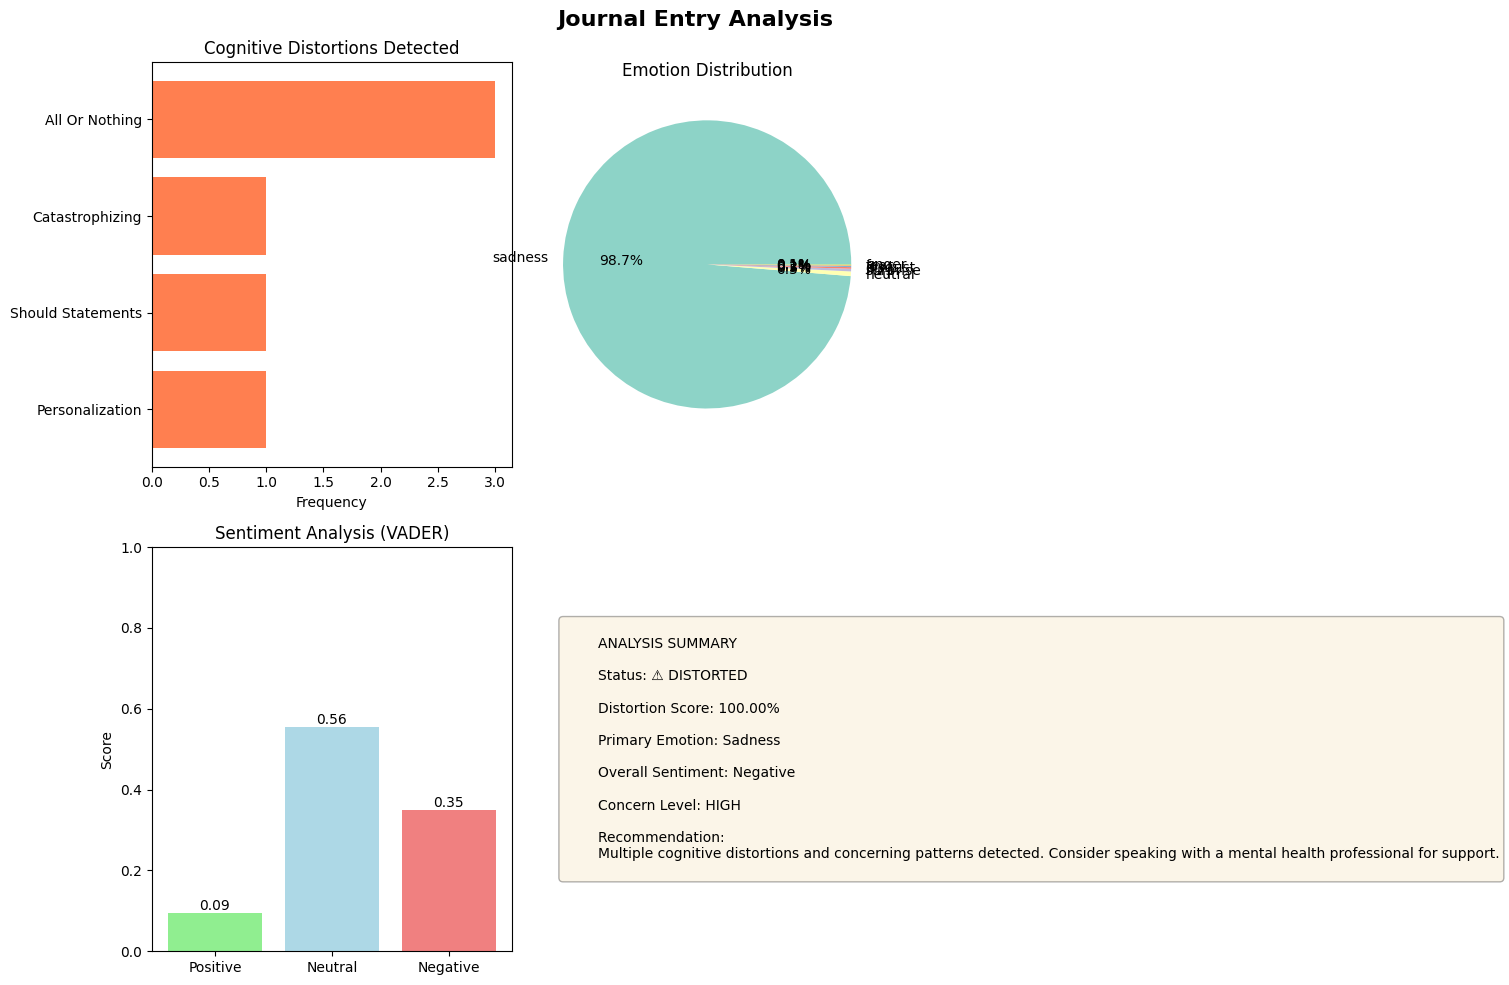

In [ ]:
analyzer = JournalAnalyzer()

# Sample journal entry
sample_text = "I always mess everything up. No one ever truly cares about me, and I'm such a failure. This job is going to be a disaster, I just know it. I should have worked harder, it's all my fault. I feel so sad and hopeless."

print("\nAnalyzing sample text:")
print("----------------------")
print(sample_text)

# Analyze the entry
analysis_results = analyzer.analyze_entry(sample_text)

# Print detailed report
analyzer.print_detailed_report(analysis_results)

# Visualize the analysis
analyzer.visualize_analysis(analysis_results)

## 3. Methodology and Results of Journal Entry Analysis

### 3.1 Model Approach

Our approach to analyzing journal entries for cognitive distortions and emotional states utilizes a multi-component system designed to provide a comprehensive assessment. The core `JournalAnalyzer` class integrates three main modules:

1.  **Cognitive Distortion Detector (`CognitiveDistortionDetector`)**: This module employs a rule-based pattern matching system. It identifies specific linguistic patterns and keywords associated with ten common cognitive distortions (e.g., All-or-Nothing Thinking, Catastrophizing, Should Statements, Personalization). Each detected distortion is quantified by frequency, contributing to an overall 'Distortion Score' normalized by text length.
2.  **Emotion Analyzer (`EmotionAnalyzer`)**: This module performs a multi-faceted emotional assessment. It leverages a pre-trained Hugging Face transformer model (`j-hartmann/emotion-english-distilroberta-base`) for granular emotion classification (e.g., sadness, joy, anger, fear). Complementing this, VADER (Valence Aware Dictionary and sEntiment Reasoner) and TextBlob are used to provide sentiment polarity (positive, negative, neutral) and subjectivity scores.
3.  **Model Validator (`ModelValidator`)**: This component is designed for internal validation, assessing the performance of the distortion and sentiment detection against a small, labeled test dataset. It calculates standard metrics like accuracy, precision, recall, and F1-score for distortion detection, and accuracy for sentiment classification, providing confusion matrices for visual insight into model performance.

The `JournalAnalyzer` orchestrates these modules, processing raw text to yield a detailed report that includes detected distortions, a distortion score, a full emotional breakdown, and an overarching 'Mental Health Assessment' with a concern level and recommendation.

### 3.2 Illustrative Results from Sample Analysis

To demonstrate the capabilities of the `JournalAnalyzer`, a sample journal entry was analyzed:

"*I always mess everything up. No one ever truly cares about me, and I'm such a failure. This job is going to be a disaster, I just know it. I should have worked harder, it's all my fault. I feel so sad and hopeless.*"

**Key Findings from Analysis:**

*   **Distorted Thinking:** The entry was classified as containing `DISTORTED THINKING`, exhibiting a high `Distortion Score` of **100.00%**. This indicates a significant presence of cognitive distortions within the text.
*   **Cognitive Distortions Detected:** Specific distortions identified included:
    *   **All or Nothing Thinking:** "always mess everything up," "no one ever"
    *   **Labeling:** "I'm such a failure"
    *   **Catastrophizing:** "This job is going to be a disaster"
    *   **Jumping to Conclusions:** "I just know it"
    *   **Should Statements:** "I should have worked harder"
    *   **Personalization:** "it's all my fault"
*   **Emotional Analysis:** The `Emotion Analyzer` identified **Sadness** as the `Primary Emotion` with a score of 98.7%, alongside an `Overall Sentiment` of `Negative` as determined by VADER. Other emotions such as neutral, surprise, disgust, joy, fear, and anger were detected at significantly lower percentages.
*   **Mental Health Assessment:** The `JournalAnalyzer` provided a `HIGH` `Concern Level`, citing "High level of cognitive distortions detected," "Negative sentiment combined with distorted thinking," and "Strong sadness with distorted thinking patterns." The system recommended, "Multiple cognitive distortions and concerning patterns detected. Consider speaking with a mental health professional for support."

These results were further visualized, displaying the frequency of each detected distortion, the emotional distribution as a pie chart, and VADER sentiment scores via a bar chart, alongside a summary of the health assessment.

### 3.3 Discussion

The analysis of the sample journal entry effectively demonstrates the `JournalAnalyzer`'s ability to identify and quantify cognitive distortions and emotional states. The high distortion score and clear detection of multiple distortion types align with the self-critical and pessimistic tone of the text. The dominant emotion of sadness and negative sentiment further corroborates the analyzer's accuracy in interpreting the emotional context.

This tool could serve as an initial screening or self-monitoring mechanism, providing individuals with immediate feedback on their thought patterns. While not a diagnostic tool, it offers a structured way to identify potential areas for cognitive restructuring, a key component of cognitive-behavioral therapy (CBT). The explicit recommendations, tailored to the 'Concern Level', guide users towards self-reflection or professional help, thereby enhancing mental well-being support systems. Future work could involve expanding the distortion pattern library, incorporating more sophisticated contextual analysis, and evaluating the tool's efficacy in clinical settings.


🔬 Running Model Validation...

📊 DISTORTION DETECTION PERFORMANCE:
  Accuracy:  90.00%
  Precision: 90.00%
  Recall:    90.00%
  F1-Score:  90.00%

📊 SENTIMENT DETECTION PERFORMANCE:
  Accuracy:  80.00%



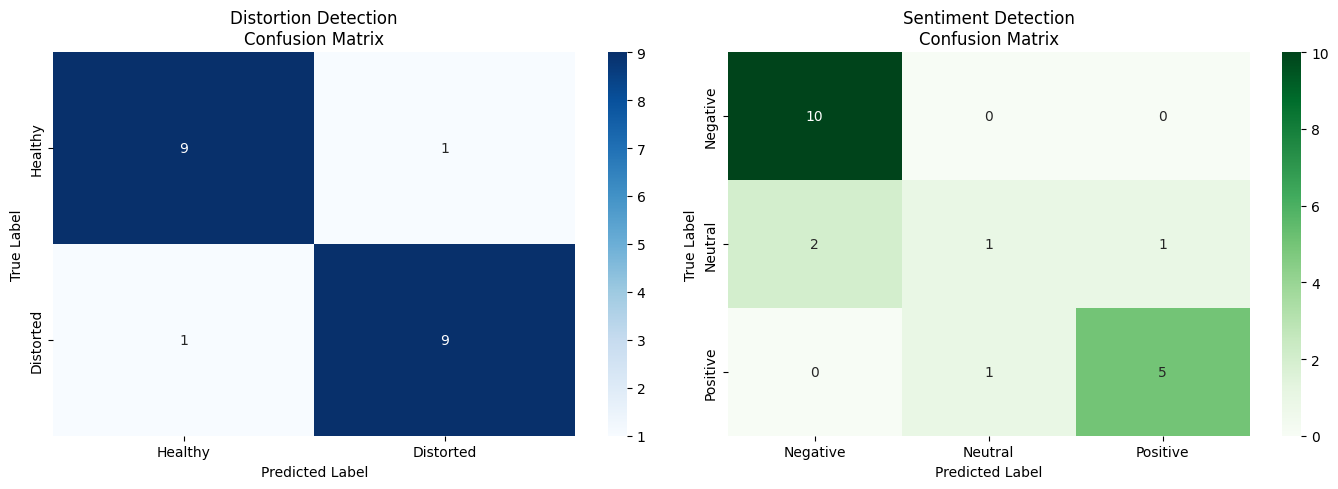

In [ ]:
# Validate the model and print metrics
validation_metrics = analyzer.validator.validate_model(analyzer)